In [ ]:

import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tqdm
import re
import gc
from functools import partial
from pathlib import Path

# This notebook derives the genotype-AUC tables
# from raw barcode-count parquet files (under dump/) that are not part of the
# public data deposit, so it is not runnable from the public repository as-is.
# The runnable, repo-relative reproduction is ../analysis.py, which starts from
# the deposited data/raw/*_auc_per_genotype.csv tables.
def _repo_root(start: Path) -> Path:
    for a in (start, *start.parents):
        if (a / "data" / "processed" / "Epistasis_Combined.parquet").exists():
            return a
    return start

PROJECT_PATH = _repo_root(Path.cwd())
EXP_ID = "20240723"


In [ ]:
sign_pos = [19,  37,  67, 102, 162, 180, 235, 236, 237, 241, 261, 271, 272]

intended = {19: ['L','P'], 37: ['Q','K'], 67: ['M','L','V'],
            102: ['E','K'], 162: ['R','S','H','N'],
            180: ['M','T'], 235: ['A','T'], 236: ['G','S'],
            237: ['E','K'], 241: ['R','S','C'], 261: ['T','M'],
            271: ['R','L','Q'], 272:['N','D']}

drugs = ['Ampicillin', 'Aztreonam'] # Excluding the BLT1 samples

In [ ]:
# Read sample metadata
meta = pd.read_excel(PROJECT_PATH / 'data' / EXP_ID / 'reference' / 'metadata.xlsx')
meta = meta.set_index('Sample Name')
meta['Timepoint'] = meta['Timepoint'].str.strip('h').astype(int)
meta

,Drug,Concentration,Timepoint,Replicate,OD600
Sample Name,,,,,
AMP_12_2_1_12h_S37,Ampicillin,12.2,12,1,3.266
AMP_12_2_1_3h_S18,Ampicillin,12.2,3,1,0.340
AMP_12_2_1_6h_S24,Ampicillin,12.2,6,1,1.484
AMP_12_2_1_9h_S30,Ampicillin,12.2,9,1,2.612
AMP_12_2_2_12h_S63,Ampicillin,12.2,12,2,3.414
...,...,...,...,...,...
BLT1_2_UT_S6,BLT1,0.0,8,2,NaN
BLT1_3_0_5uM_S12,BLT1,0.5,8,3,NaN
BLT1_3_1uM_S11,BLT1,1.0,8,3,NaN


/tmp/ipykernel_55152/2398014720.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


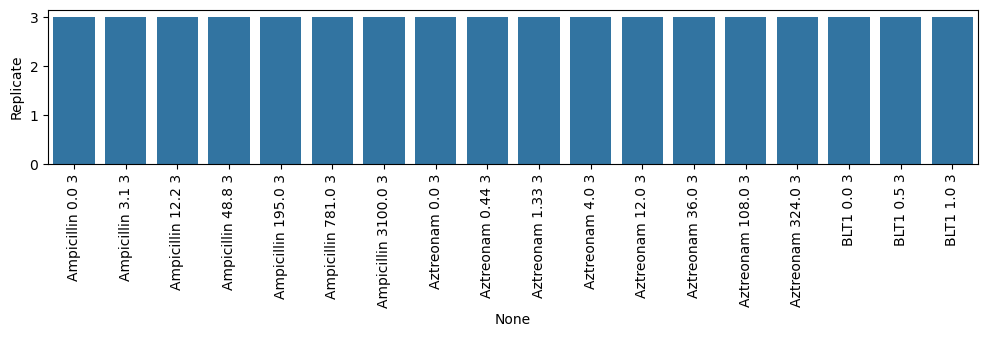

In [ ]:
# Check if we have correct number of replicates per condition
# Revise metadata sheet for inconsistencies
meta_check = meta.groupby(['Drug','Concentration','Timepoint'])['Replicate'].nunique().reset_index()
fig, ax = plt.subplots(1,1,figsize=(12,2))
sns.barplot(x=meta_check['Drug']+' '+meta_check['Concentration'].astype(str)+' '+meta_check['Replicate'].astype(str),
            y=meta_check['Replicate'], ax=ax);
ax.set_xticklabels(ax.get_xticklabels(), rotation=90);

In [ ]:
matchbook = pl.read_parquet(PROJECT_PATH / "dump/20240117_pacbio/matchbook_one2one.lz4.parquet")
matchbook

read_id,barcode,mut_profile,mut_profile_masked,number of mutations,unique_mut_profile_count,unique_read_count
str,str,str,str,u32,u32,u32
"""m84161_240111_002317_s3/228117…","""ACGGTTATCGATATT""","""LQLERTTGKSMQN""","""..L..TT.KSMQ.""",7,1,1
"""m84161_240111_002317_s3/145033…","""GCTAATACCTCAGTA""","""LQVENMAGKRMQN""","""..V.N...K.MQ.""",6,1,1
"""m84161_240111_002317_s3/247664…","""TCTGAGGATCTTCCA""","""LQMEHMTGECMRD""","""....H.T..CM.D""",5,1,1
"""m84161_240111_002317_s3/716320…","""TCTCGTTCTTATGCC""","""LKMKHTAGKCMRD""",""".K.KHT..KCM.D""",8,1,1
"""m84161_240111_002317_s3/105251…","""TCGATCGCGGGCAGG""","""LKVESTTGKRTQN""",""".KV.STT.K..Q.""",7,1,1
…,…,…,…,…,…,…
"""N/A""","""TGTAGTGTGTGCACG""","""LQMERMAGERTRN""",""".............""",0,1,1
"""N/A""","""TAAGGTTTGATCTAT""","""LQMERMAGERTRN""",""".............""",0,1,1
"""N/A""","""GTGATTTAAATCGGA""","""LQMERMAGERTRN""",""".............""",0,1,1


In [ ]:
matchbook['barcode'].n_unique()

3457235

In [ ]:
# Read barcode counts in all samples
dfs = dict()
for comb in (PROJECT_PATH / "dump" / EXP_ID / "combined-barcode-counts").glob("*combined-barcode-counts.parquet"):
    drug = comb.stem.split('-')[0]
    df = pl.read_parquet(comb)
    # filter barcodes that exist in non-negligible numbers
    df = df.filter(pl.sum_horizontal(pl.exclude('barcode'))>10)
    # assign genotypes to known barcodes
    df = df.join(matchbook[['barcode','mut_profile_masked','mut_profile']], on='barcode', how='left', coalesce=True)
    # manually add spiked wt annotation
    df = df.with_columns(pl.when(pl.col("barcode") == "ACAGCATCCAATGCG")
        .then(pl.lit("............."))
        .otherwise("mut_profile_masked")
        .alias("mut_profile_masked"))
    # manually add spiked dead annotation
    df = df.with_columns(pl.when(pl.col("barcode") == "AGCCTCAAAATTACT")
        .then(pl.lit("XXXXXXXXXXXXX"))
        .otherwise("mut_profile_masked")
        .alias("mut_profile_masked"))
    # filter known ones
    df = df.filter(pl.col("mut_profile_masked").is_not_null())
    # filter out noisy barcodes
    noisy_barcodes = ['TGTGGTGTACGGGTT', 'GTGCGCGATCTCCTA']
    df = df.filter(~pl.col("barcode").is_in(noisy_barcodes))
    # aggregate by genotype
    df = df.group_by('mut_profile_masked').agg(pl.exclude(['barcode','mut_profile']).sum())
    dfs[drug] = df
    # save tables for later use
    dfs[drug].write_csv(PROJECT_PATH / 'dump' / EXP_ID / 'combined-genotype-counts' / f"{drug}-combined-genotype-counts.csv")

dfs['Ampicillin']

mut_profile_masked,AMP_12_2_1_12h_S37,AMP_12_2_1_3h_S18,AMP_12_2_1_6h_S24,AMP_12_2_1_9h_S30,AMP_12_2_2_12h_S63,AMP_12_2_2_3h_S44,AMP_12_2_2_6h_S50,AMP_12_2_2_9h_S56,AMP_12_2_3_12h_S89,AMP_12_2_3_3h_S70,AMP_12_2_3_6h_S76,AMP_12_2_3_9h_S82,AMP_195_1_12h_S35,AMP_195_1_3h_S16,AMP_195_1_6h_S22,AMP_195_1_9h_S28,AMP_195_2_12h_S61,AMP_195_2_3h_S42,AMP_195_2_6h_S48,AMP_195_2_9h_S54,AMP_195_3_12h_S87,AMP_195_3_3h_S68,AMP_195_3_6h_S74,AMP_195_3_9h_S80,AMP_1_to_S13,AMP_2_to_S39,AMP_3_1_1_12h_S38,AMP_3_1_1_3h_S19,AMP_3_1_1_6h_S25,AMP_3_1_1_9h_S31,AMP_3_1_2_12h_S64,AMP_3_1_2_3h_S45,AMP_3_1_2_6h_S51,AMP_3_1_2_9h_S57,AMP_3_1_3_12h_S90,AMP_3_1_3_3h_S71,…,AMP_3_to_S65,AMP_48_8_1_12h_S36,AMP_48_8_1_3h_S17,AMP_48_8_1_6h_S23,AMP_48_8_1_9h_S29,AMP_48_8_2_12h_S62,AMP_48_8_2_3h_S43,AMP_48_8_2_6h_S49,AMP_48_8_2_9h_S55,AMP_48_8_3_12h_S88,AMP_48_8_3_3h_S69,AMP_48_8_3_6h_S75,AMP_48_8_3_9h_S81,AMP_781_1_12h_S34,AMP_781_1_3h_S15,AMP_781_1_6h_S21,AMP_781_1_9h_S27,AMP_781_2_12h_S60,AMP_781_2_3h_S41,AMP_781_2_6h_S47,AMP_781_2_9h_S53,AMP_781_3_12h_S86,AMP_781_3_3h_S67,AMP_781_3_6h_S73,AMP_781_3_9h_S79,AMP_UT1_12h_S32,AMP_UT_1_3h_S14,AMP_UT1_6h_S20,AMP_UT1_9h_S26,AMP_UT_2_12h_S58,AMP_UT_2_3h_S40,AMP_UT_2_6h_S46,AMP_UT_2_9h_S52,AMP_UT_3_12h_S84,AMP_UT_3_3h_S66,AMP_UT_3_6h_S72,AMP_UT_3_9h_S78
str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,…,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
""".KVK.TT.KC..D""",28,47,40,24,40,61,43,32,20,30,27,16,22,30,24,33,26,43,22,29,29,30,16,28,53,52,44,54,80,68,72,48,63,65,70,47,…,77,17,21,18,16,19,26,14,28,27,38,52,23,2,14,10,4,14,14,2,18,12,16,4,4,94,100,93,83,85,38,44,63,62,54,46,27
"""PK.KNT..K.M.D""",22,17,32,19,40,18,28,22,20,32,16,10,53,37,60,47,34,28,47,14,29,12,20,29,16,14,22,6,16,24,14,12,20,8,20,14,…,11,46,44,43,44,31,34,23,24,37,34,20,54,0,25,0,2,0,16,4,0,4,18,4,8,9,11,16,14,22,10,14,12,8,18,20,20
"""P..KTT.S.SM..""",0,0,0,0,0,0,0,2,0,0,4,0,0,0,0,0,0,0,0,0,0,2,0,0,2,0,0,2,0,0,2,0,0,0,0,2,…,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,2,0
"""P.LKS..S..M..""",77,44,55,46,64,42,89,98,52,48,62,60,80,58,87,87,132,103,148,108,108,119,104,121,36,47,36,53,41,48,26,34,51,30,49,37,…,45,90,58,90,77,94,61,80,79,123,73,86,85,2,37,6,2,2,86,3,0,2,54,8,4,36,33,32,37,41,58,32,41,56,47,60,43
"""....HTT..S...""",125,95,93,90,171,149,150,167,158,154,133,137,176,219,245,256,232,196,258,257,269,274,260,232,111,106,86,66,83,83,85,109,104,111,114,119,…,119,164,148,125,127,191,182,240,194,277,202,232,316,12,97,6,16,10,105,17,23,6,80,4,18,122,116,72,106,119,107,76,117,130,77,95,104
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
""".K..HT.S.CM..""",111,101,124,93,108,80,103,93,76,88,124,97,17,36,19,8,8,48,26,22,10,67,18,17,54,59,97,61,77,61,62,100,57,77,58,56,…,82,113,103,118,96,77,87,85,117,102,99,128,147,8,32,17,30,7,12,8,9,2,36,13,14,73,59,62,52,39,35,68,53,67,46,89,62
"""PK...T.SKC.LD""",4,0,10,21,8,22,12,4,7,14,2,16,4,14,19,8,0,0,12,0,20,10,26,24,16,32,9,11,33,10,31,20,20,15,30,14,…,26,6,20,12,10,8,8,2,4,18,12,14,10,2,0,0,0,12,0,8,4,0,0,0,0,12,17,12,25,6,18,28,21,18,25,24,36
"""..V...TS.SMQ.""",51,41,47,25,29,42,35,32,58,72,68,52,14,12,4,15,29,36,36,22,20,14,18,16,87,77,84,67,113,63,92,88,75,68,85,86,…,86,8,12,31,10,31,59,14,20,18,35,34,31,2,28,0,4,7,22,10,18,12,18,4,2,71,53,98,71,78,51,87,77,82,85,104,95


In [ ]:
def get_t0(sample):
    """ Returns the corresponding T0 sample for any sample
    for log-fold change calculations
    """
    rep = meta.loc[sample,'Replicate']
    drug = meta.loc[sample, 'Drug']
    selected = meta[(meta['Drug']==drug) & (meta['Replicate']==rep) & (meta['Timepoint']==0)]
    if len(selected)>1:
        raise
    else:
        return selected.index.values[0]
get_t0("BLT1_3_1uM_S11")

'BLT1_3_to_S9'

In [ ]:
df_norm = dict()
df_norm_od = dict()
df_fc = dict()
for drug in drugs:
    # normalize every sample across all genotypes
    df_norm[drug] = dfs[drug].select([
        pl.col('mut_profile_masked'),
        *[(pl.col(col) / pl.col(col).sum()).alias(col) 
        for col in dfs[drug].columns[1:]]
    ])
    # multiply each freq with OD600 measurement of that sample
    df_norm_od[drug] = df_norm[drug].select([
        pl.col('mut_profile_masked'),
        *[(pl.col(col) * meta.loc[col,'OD600']).alias(col) 
        for col in df_norm[drug].columns[1:]]
    ])
    # calculate log fold changes to the T0s
    df_fc[drug] = df_norm_od[drug].select([
        pl.col('mut_profile_masked'),
        *[(pl.col(col) / pl.col(get_t0(col))).alias(col) 
        for col in df_norm_od[drug].columns[1:]]
    ])

In [ ]:

df_norm_od['Ampicillin']

mut_profile_masked,AMP_12_2_1_12h_S37,AMP_12_2_1_3h_S18,AMP_12_2_1_6h_S24,AMP_12_2_1_9h_S30,AMP_12_2_2_12h_S63,AMP_12_2_2_3h_S44,AMP_12_2_2_6h_S50,AMP_12_2_2_9h_S56,AMP_12_2_3_12h_S89,AMP_12_2_3_3h_S70,AMP_12_2_3_6h_S76,AMP_12_2_3_9h_S82,AMP_195_1_12h_S35,AMP_195_1_3h_S16,AMP_195_1_6h_S22,AMP_195_1_9h_S28,AMP_195_2_12h_S61,AMP_195_2_3h_S42,AMP_195_2_6h_S48,AMP_195_2_9h_S54,AMP_195_3_12h_S87,AMP_195_3_3h_S68,AMP_195_3_6h_S74,AMP_195_3_9h_S80,AMP_1_to_S13,AMP_2_to_S39,AMP_3_1_1_12h_S38,AMP_3_1_1_3h_S19,AMP_3_1_1_6h_S25,AMP_3_1_1_9h_S31,AMP_3_1_2_12h_S64,AMP_3_1_2_3h_S45,AMP_3_1_2_6h_S51,AMP_3_1_2_9h_S57,AMP_3_1_3_12h_S90,AMP_3_1_3_3h_S71,…,AMP_3_to_S65,AMP_48_8_1_12h_S36,AMP_48_8_1_3h_S17,AMP_48_8_1_6h_S23,AMP_48_8_1_9h_S29,AMP_48_8_2_12h_S62,AMP_48_8_2_3h_S43,AMP_48_8_2_6h_S49,AMP_48_8_2_9h_S55,AMP_48_8_3_12h_S88,AMP_48_8_3_3h_S69,AMP_48_8_3_6h_S75,AMP_48_8_3_9h_S81,AMP_781_1_12h_S34,AMP_781_1_3h_S15,AMP_781_1_6h_S21,AMP_781_1_9h_S27,AMP_781_2_12h_S60,AMP_781_2_3h_S41,AMP_781_2_6h_S47,AMP_781_2_9h_S53,AMP_781_3_12h_S86,AMP_781_3_3h_S67,AMP_781_3_6h_S73,AMP_781_3_9h_S79,AMP_UT1_12h_S32,AMP_UT_1_3h_S14,AMP_UT1_6h_S20,AMP_UT1_9h_S26,AMP_UT_2_12h_S58,AMP_UT_2_3h_S40,AMP_UT_2_6h_S46,AMP_UT_2_9h_S52,AMP_UT_3_12h_S84,AMP_UT_3_3h_S66,AMP_UT_3_6h_S72,AMP_UT_3_9h_S78
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
""".KVK.TT.KC..D""",0.000033,0.000005,0.000018,0.000025,0.00004,0.000008,0.000022,0.000024,0.000025,0.000004,0.000012,0.000012,0.000031,0.000002,0.000012,0.000033,0.000033,0.000004,0.00001,0.000028,0.000038,0.000002,0.000007,0.000023,2.2108e-7,2.2115e-7,0.000051,0.000007,0.00004,0.000062,0.000075,0.000008,0.000037,0.000055,0.000075,0.000007,…,2.6657e-7,0.000021,0.000002,0.00001,0.000015,0.000021,0.000002,0.000007,0.000023,0.000027,0.000004,0.000023,0.000016,0.000005,4.7566e-7,0.000005,0.000006,0.000028,5.7533e-7,0.000001,0.000023,0.000021,7.6932e-7,0.000002,0.000004,0.000103,0.000015,0.000044,0.000058,0.000083,0.000007,0.000022,0.000049,0.00006,0.000009,0.000018,0.000019
"""PK.KNT..K.M.D""",0.000026,0.000002,0.000015,0.00002,0.00004,0.000002,0.000014,0.000016,0.000025,0.000004,0.000007,0.000007,0.000074,0.000002,0.000031,0.000047,0.000044,0.000002,0.000021,0.000014,0.000038,9.2267e-7,0.000009,0.000024,6.6741e-8,5.9539e-8,0.000026,8.2429e-7,0.000008,0.000022,0.000015,0.000002,0.000012,0.000007,0.000022,0.000002,…,3.8082e-8,0.000056,0.000005,0.000024,0.000041,0.000034,0.000003,0.000012,0.00002,0.000036,0.000003,0.000009,0.000037,0.0,8.4939e-7,0.0,0.000003,0.0,6.5752e-7,0.000003,0.0,0.000007,8.6548e-7,0.000002,0.000009,0.00001,0.000002,0.000008,0.00001,0.000022,0.000002,0.000007,0.000009,0.000008,0.000003,0.000008,0.000014
"""P..KTT.S.SM..""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000001,0.0,0.0,0.000002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.5378e-7,0.0,0.0,8.3426e-9,0.0,0.0,2.7476e-7,0.0,0.0,0.000002,0.0,0.0,0.0,0.0,2.8233e-7,…,0.0,0.0,0.0,0.0,0.0,0.000002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.5977e-7,0.0,7.8753e-7,0.0
"""P.LKS..S..M..""",0.00009,0.000004,0.000025,0.000048,0.000065,0.000006,0.000045,0.000072,0.000065,0.000006,0.000028,0.000044,0.000112,0.000003,0.000045,0.000087,0.00017,0.000009,0.000067,0.000105,0.00014,0.000009,0.000048,0.000099,1.5017e-7,1.9988e-7,0.000042,0.000007,0.000021,0.000044,0.000027,0.000006,0.00003,0.000025,0.000053,0.000005,…,1.5579e-7,0.00011,0.000006,0.00005,0.000073,0.000104,0.000005,0.00004,0.000065,0.000121,0.000007,0.000039,0.000058,0.000005,0.000001,0.000003,0.000003,0.000004,0.000004,0.000002,0.0,0.000003,0.000003,0.000005,0.000004,0.000039,0.000005,0.000015,0.000026,0.00004,0.000011,0.000016,0.000032,0.000054,0.000008,0.000024,0.000031
"""....HTT..S...""",0.000146,0.00001,0.00004

In [ ]:
df_fc['Ampicillin']

mut_profile_masked,AMP_12_2_1_12h_S37,AMP_12_2_1_3h_S18,AMP_12_2_1_6h_S24,AMP_12_2_1_9h_S30,AMP_12_2_2_12h_S63,AMP_12_2_2_3h_S44,AMP_12_2_2_6h_S50,AMP_12_2_2_9h_S56,AMP_12_2_3_12h_S89,AMP_12_2_3_3h_S70,AMP_12_2_3_6h_S76,AMP_12_2_3_9h_S82,AMP_195_1_12h_S35,AMP_195_1_3h_S16,AMP_195_1_6h_S22,AMP_195_1_9h_S28,AMP_195_2_12h_S61,AMP_195_2_3h_S42,AMP_195_2_6h_S48,AMP_195_2_9h_S54,AMP_195_3_12h_S87,AMP_195_3_3h_S68,AMP_195_3_6h_S74,AMP_195_3_9h_S80,AMP_1_to_S13,AMP_2_to_S39,AMP_3_1_1_12h_S38,AMP_3_1_1_3h_S19,AMP_3_1_1_6h_S25,AMP_3_1_1_9h_S31,AMP_3_1_2_12h_S64,AMP_3_1_2_3h_S45,AMP_3_1_2_6h_S51,AMP_3_1_2_9h_S57,AMP_3_1_3_12h_S90,AMP_3_1_3_3h_S71,…,AMP_3_to_S65,AMP_48_8_1_12h_S36,AMP_48_8_1_3h_S17,AMP_48_8_1_6h_S23,AMP_48_8_1_9h_S29,AMP_48_8_2_12h_S62,AMP_48_8_2_3h_S43,AMP_48_8_2_6h_S49,AMP_48_8_2_9h_S55,AMP_48_8_3_12h_S88,AMP_48_8_3_3h_S69,AMP_48_8_3_6h_S75,AMP_48_8_3_9h_S81,AMP_781_1_12h_S34,AMP_781_1_3h_S15,AMP_781_1_6h_S21,AMP_781_1_9h_S27,AMP_781_2_12h_S60,AMP_781_2_3h_S41,AMP_781_2_6h_S47,AMP_781_2_9h_S53,AMP_781_3_12h_S86,AMP_781_3_3h_S67,AMP_781_3_6h_S73,AMP_781_3_9h_S79,AMP_UT1_12h_S32,AMP_UT_1_3h_S14,AMP_UT1_6h_S20,AMP_UT1_9h_S26,AMP_UT_2_12h_S58,AMP_UT_2_3h_S40,AMP_UT_2_6h_S46,AMP_UT_2_9h_S52,AMP_UT_3_12h_S84,AMP_UT_3_3h_S66,AMP_UT_3_6h_S72,AMP_UT_3_9h_S78
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
""".KVK.TT.KC..D""",147.951708,21.422175,82.80414,113.320274,182.705826,36.202127,97.379669,107.002326,93.459255,13.664446,45.42276,43.835003,139.342481,7.311554,55.609171,148.785985,151.100731,17.057376,44.910332,127.348859,140.766905,8.653018,27.780007,85.838277,1.0,1.0,231.986478,33.556535,181.552158,282.681491,339.953274,35.85758,168.418165,246.808705,283.05606,24.889023,…,1.0,94.057111,10.516554,45.394395,68.144938,94.67584,9.36264,31.901041,103.404528,99.448026,13.743308,87.752854,58.673441,22.718918,2.151539,24.757186,28.029856,124.415357,2.601574,5.800423,104.206873,78.380338,2.885935,9.057377,16.70401,466.430457,68.2891,199.332849,260.37545,376.572195,32.404997,99.552336,222.717152,223.22433,32.866721,67.94778,72.129105
"""PK.KNT..K.M.D""",385.070741,25.666729,219.43097,297.170615,678.621639,39.67821,235.52292,273.238082,654.214783,102.027864,188.420336,191.778137,1111.968832,29.870746,460.513447,701.942973,733.917835,41.255049,356.366402,228.349679,985.368338,24.228449,243.075065,622.32751,1.0,1.0,384.227604,12.350669,120.278305,330.48792,245.521809,33.296324,198.588313,112.826837,566.112121,51.89626,…,1.0,843.056014,72.989891,359.214677,620.757792,573.749829,45.475681,194.661452,329.206252,953.9644,86.076507,236.257684,964.285244,0.0,12.726739,0.0,46.424449,0.0,11.043418,43.088856,0.0,182.887454,22.726735,63.401639,233.856146,147.930404,24.882841,113.59829,145.480862,362.015623,31.674057,117.65276,157.568597,201.621976,76.689017,206.797592,374.002767
"""P..KTT.S.SM..""",0.0,0.0,0.0,0.0,NaN,NaN,NaN,inf,NaN,NaN,inf,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,inf,NaN,NaN,1.0,NaN,0.0,32.935118,0.0,0.0,inf,NaN,NaN,NaN,NaN,inf,…,NaN,0.0,0.0,0.0,0.0,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,inf,NaN,inf,NaN
"""P.LKS..S..M..""",598.99893,29.525126,167.62088,319.762533,323.428185,27.577763,222.995106,362.555754,415.78984,37.410217,178.47593,281.274601,745.974898,20.81085,296.775332,577.484999,848.736019,45.205001,334.26491,524.718411,897.02497,58.731555,308.975416,634.726372,1.0,1.0,279.438258,48.487813,136.983625,293.76704,135.820575,28.101153,150.842612,126.029977,339.038259,33.526631,…,1.0,733.092186,42.761754,334.153188,482.811616,518.225652,24.303024,201.684391,322.785563,775.203503,45.176101,248.333077,371.031565,33.447297,8.371366,21.868848,20.633088,19.664433,17.681217,9.626234,0.0,22.352911,16.666272,30.9963

In [ ]:
df_norm_od['Ampicillin'].select(pl.col([col for col in df_norm_od['Ampicillin'].columns if 'to' in col]))

AMP_1_to_S13,AMP_2_to_S39,AMP_3_to_S65
f64,f64,f64
2.2108e-7,2.2115e-7,2.6657e-7
6.6741e-8,5.9539e-8,3.8082e-8
8.3426e-9,0.0,0.0
1.5017e-7,1.9988e-7,1.5579e-7
4.6301e-7,4.5080e-7,4.1198e-7
…,…,…
2.2525e-7,2.5092e-7,2.8388e-7
6.6741e-8,1.3609e-7,9.0012e-8
3.6290e-7,3.2747e-7,2.9773e-7


/tmp/ipykernel_62345/3926474226.py:1: RuntimeWarning: divide by zero encountered in log10
  fc_all_amp = np.log10(df_fc['Ampicillin'].select(pl.exclude('mut_profile_masked')).to_numpy().flatten())
/tmp/ipykernel_62345/3926474226.py:2: RuntimeWarning: divide by zero encountered in log10
  fc_all_azt = np.log10(df_fc['Aztreonam'].select(pl.exclude('mut_profile_masked')).to_numpy().flatten())


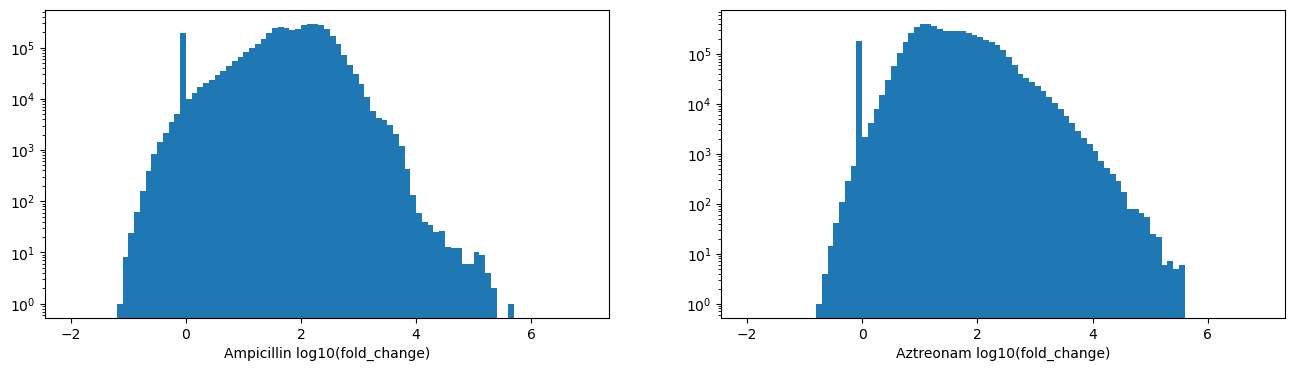

In [ ]:
fc_all_amp = np.log10(df_fc['Ampicillin'].select(pl.exclude('mut_profile_masked')).to_numpy().flatten())
fc_all_azt = np.log10(df_fc['Aztreonam'].select(pl.exclude('mut_profile_masked')).to_numpy().flatten())
fig, axes = plt.subplots(1,2,figsize=(16,4))
axes[0].hist(np.ma.masked_invalid(fc_all_amp),bins=np.arange(-2,7,0.1));
axes[0].set_yscale('log')
axes[0].set_xlabel('Ampicillin log10(fold_change)')
axes[1].hist(np.ma.masked_invalid(fc_all_azt),bins=np.arange(-2,7,0.1));
axes[1].set_yscale('log')
axes[1].set_xlabel('Aztreonam log10(fold_change)');

In [ ]:
metag = meta.reset_index().groupby(['Drug','Concentration','Replicate','Timepoint','OD600']
                                   )['Sample Name'].agg('first').to_frame().reset_index()
# metag = metag[metag.Drug=="Ampicillin"]
# metag = metag[metag.Drug=="Aztreonam"]
# metag.to_csv('metag.csv')
# metag = metag[metag.Concentration<3000]
metag

,Drug,Concentration,Replicate,Timepoint,OD600,Sample Name
0,Ampicillin,0.0,1,0,0.014,AMP_1_to_S13
1,Ampicillin,0.0,1,3,0.440,AMP_UT_1_3h_S14
2,Ampicillin,0.0,1,6,1.678,AMP_UT1_6h_S20
3,Ampicillin,0.0,1,9,2.298,AMP_UT1_9h_S26
4,Ampicillin,0.0,1,12,3.474,AMP_UT1_12h_S32
...,...,...,...,...,...,...
172,Aztreonam,324.0,2,12,1.120,AZT_324_2_12h_S150
173,Aztreonam,324.0,3,3,0.128,AZT_324_3_3h_S159
174,Aztreonam,324.0,3,6,0.088,AZT_324_3_6h_S167
175,Aztreonam,324.0,3,9,0.188,AZT_324_3_9h_S175


In [ ]:
# Aggregate frequency vs. time vectors for AUC calculation
freq_time_vectors = dict()

# Iterate over every drug
for drug in drugs:
    freq_time_vectors[drug] = list()
    # select drug > iterate over all experimental conditions
    # > aggregate over timepoint columns
    for ix, row in (metag.query(f'Drug=="{drug}"')
                    .groupby(['Drug','Concentration','Replicate'])['Sample Name']
                    .agg(list).items()):
        # Add T0 sample as timepoint 0 for all vectors
        if row[0] != get_t0(row[0]):
            row.insert(0, get_t0(row[0]))
        # Tag them with a string "{drug} {concentration} {replicate}"
        freq_time_vectors[drug].append((" ".join(str(i) for i in ix),row))

freq_time_vectors['Ampicillin'][6:9]

[('Ampicillin 12.2 1',
  ['AMP_1_to_S13',
   'AMP_12_2_1_3h_S18',
   'AMP_12_2_1_6h_S24',
   'AMP_12_2_1_9h_S30',
   'AMP_12_2_1_12h_S37']),
 ('Ampicillin 12.2 2',
  ['AMP_2_to_S39',
   'AMP_12_2_2_3h_S44',
   'AMP_12_2_2_6h_S50',
   'AMP_12_2_2_9h_S56',
   'AMP_12_2_2_12h_S63']),
 ('Ampicillin 12.2 3',
  ['AMP_3_to_S65',
   'AMP_12_2_3_3h_S70',
   'AMP_12_2_3_6h_S76',
   'AMP_12_2_3_9h_S82',
   'AMP_12_2_3_12h_S89'])]

In [ ]:
# Calculate AUC of the estimated cell count fold change to T0
#
df_auc = dict()
for drug in drugs:
    # Keep the genotype string as index
    df_cols = [df_fc[drug].select(pl.col('mut_profile_masked')).to_series()]
    # Calculate and add new columns
    for condition_tag, sample_names in freq_time_vectors[drug]:
        auc_values = np.log10(np.trapz(df_fc[drug].select(sample_names).to_numpy(),
                                          [0, 3, 6, 9, 12], axis=1))
        df_cols.append(pl.Series(condition_tag, auc_values))

    # Create a new DataFrame from the new columns
    df_auc[drug] = pl.DataFrame(df_cols).to_pandas()

    # special case for ampicillin drop 3100 datapoint
    if drug == 'Ampicillin':
        df_auc[drug] = df_auc[drug].iloc[:,:-3]
df_auc['Ampicillin']

/tmp/ipykernel_62345/921873460.py:9: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc_values = np.log10(np.trapz(df_fc[drug].select(sample_names).to_numpy(),


,mut_profile_masked,Ampicillin 0.0 1,Ampicillin 0.0 2,Ampicillin 0.0 3,Ampicillin 3.1 1,Ampicillin 3.1 2,Ampicillin 3.1 3,Ampicillin 12.2 1,Ampicillin 12.2 2,Ampicillin 12.2 3,Ampicillin 48.8 1,Ampicillin 48.8 2,Ampicillin 48.8 3,Ampicillin 195.0 1,Ampicillin 195.0 2,Ampicillin 195.0 3,Ampicillin 781.0 1,Ampicillin 781.0 2,Ampicillin 781.0 3
0,.KVK.TT.KC..D,3.358912,3.212289,2.932051,3.265490,3.270605,3.242095,2.942537,2.998831,2.653652,2.711599,2.761566,2.800154,2.927182,2.900968,2.763027,2.301885,2.720944,2.311780
1,PK.KNT..K.M.D,3.031522,3.165900,3.357249,3.293847,3.147341,3.322158,3.343588,3.425656,3.385517,3.645910,3.409959,3.723645,3.719864,3.474259,3.617885,2.252740,2.214571,3.091943
2,P..KTT.S.SM..,0.176091,NaN,NaN,2.001324,NaN,NaN,0.176091,NaN,NaN,0.176091,NaN,NaN,0.176091,NaN,NaN,0.176091,NaN,NaN
3,P.LKS..S..M..,3.117632,3.075003,3.233116,3.269133,3.049277,3.177892,3.389294,3.366615,3.325653,3.565885,3.384740,3.499402,3.580432,3.600665,3.638922,2.310249,2.052767,2.421216
4,....HTT..S...,3.095492,3.141610,3.133052,3.060342,3.160200,3.191493,3.152615,3.307098,3.304750,3.297521,3.424476,3.538874,3.524117,3.549504,3.565749,2.480531,2.561257,2.363696
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70178,.K..HT.S.CM..,3.183274,3.083160,3.099364,3.327814,3.246002,3.056909,3.484202,3.345999,3.290246,3.498853,3.351440,3.361057,2.624987,2.706793,2.555296,2.950698,2.460520,2.456085
70179,PK...T.SKC.LD,3.160674,2.909490,3.202489,3.165107,2.986510,3.076057,3.113138,2.546426,2.794360,2.995617,2.315849,2.887129,2.981011,2.082500,3.179883,2.058368,2.687920,0.176091
70180,..V...TS.SMQ.,3.072074,3.142998,3.212530,3.155216,3.177254,3.210872,2.829594,2.750932,3.058249,2.437190,2.618352,2.691148,2.358718,2.737012,2.554399,1.910366,2.534884,2.210184
70181,PK.KSTTS.C...,3.053982,3.058712,3.043877,3.136878,2.824432,3.261295,2.649882,2.749982,2.693624,2.744042,2.395333,2.844634,2.653174,2.511875,2.474455,1.542243,2.333019,1.981022


In [ ]:
def median_trapz(row, concs, rep=3):
    rep_trapz = []
    for i in range(rep):
        rep_vector = np.array([10**row[j] for j in range(1+i,len(row),rep)])
        rep_vector = np.nan_to_num(rep_vector, 0)
        rep_trapz.append(np.trapz(rep_vector, concs))
    return np.median(rep_trapz)


In [ ]:
df_sorted = dict()
for drug in drugs:
    concs = [float(col.split(' ')[1]) for col in df_auc[drug].columns[1::3]]
    # Calculate median AUC of (AUC of fold-change vs. time) vs. conc
    median_auc = df_auc[drug].apply(partial(median_trapz,concs=concs), axis=1).sort_values(ascending=False)
    # Sort the table by the median auc2
    df_sorted[drug] = df_auc[drug].loc[median_auc.index]
    df_sorted[drug].to_csv(PROJECT_PATH / 'dump' / EXP_ID / 'misc' / f'genotype_auc_sorted_{drug.lower()}.csv')
    # Export estimated fitness by median auc2
    df_fitness_auc2 = pd.concat([df_sorted[drug]['mut_profile_masked'], median_auc.to_frame(name='auc2')], axis=1)
    df_fitness_auc2.to_csv(PROJECT_PATH / 'dump' / EXP_ID / 'misc' / f'genotype_fitness_median_auc2_{drug.lower()}.csv', index=False)
df_sorted['Ampicillin']

/tmp/ipykernel_62345/3422921004.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rep_vector = np.array([10**row[j] for j in range(1+i,len(row),rep)])
/tmp/ipykernel_62345/3422921004.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  rep_trapz.append(np.trapz(rep_vector, concs))
/tmp/ipykernel_62345/3422921004.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  rep_vector = np.array([10**row[j] for j in range(1+i,len(row),rep)])
/tmp/ipykernel_62345/3422921004.py:6: DeprecationWarning: `trapz` is deprecated. Use `trapezoid`

,mut_profile_masked,Ampicillin 0.0 1,Ampicillin 0.0 2,Ampicillin 0.0 3,Ampicillin 3.1 1,Ampicillin 3.1 2,Ampicillin 3.1 3,Ampicillin 12.2 1,Ampicillin 12.2 2,Ampicillin 12.2 3,Ampicillin 48.8 1,Ampicillin 48.8 2,Ampicillin 48.8 3,Ampicillin 195.0 1,Ampicillin 195.0 2,Ampicillin 195.0 3,Ampicillin 781.0 1,Ampicillin 781.0 2,Ampicillin 781.0 3
27594,....N..S...T.,3.470318,3.350165,3.612146,3.238971,3.283772,3.071053,3.608671,3.276458,3.281529,3.826256,2.956072,3.818090,4.011559,3.979569,3.975904,4.741949,4.758947,4.535402
5983,IKV.ST.....L.,2.339768,3.687577,3.158498,3.474543,3.675799,2.537211,3.575812,3.766868,3.166602,3.917624,4.217166,3.331044,4.151872,4.201464,3.449778,4.484850,4.429925,3.811701
4191,..VK.T..K...D,3.246056,3.381039,3.386168,3.254894,3.499717,3.572811,3.445461,3.555552,3.707558,3.688961,3.724072,3.717756,3.926324,4.054691,3.966381,4.318668,4.576903,4.574156
15454,PK.K....K....,3.297042,3.029911,3.374664,3.367117,3.155275,3.360832,3.556505,3.286163,3.568653,3.719924,3.384320,3.656833,3.866684,3.751909,3.992477,4.574223,4.295283,4.534542
44010,.K.KNT....M.D,3.195520,3.521552,3.360132,3.250648,3.487157,3.404783,3.350543,3.613922,3.519203,3.571188,3.787627,3.574253,3.848914,4.089437,3.905243,4.270981,4.564519,4.552179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41216,.K..HTTSD..QD,NaN,0.176091,NaN,NaN,0.176091,NaN,NaN,0.176091,NaN,NaN,0.176091,NaN,NaN,2.805100,NaN,NaN,0.176091,NaN
13736,..L.H..I.S.L.,0.176091,NaN,NaN,2.324444,NaN,NaN,0.176091,NaN,NaN,0.176091,NaN,NaN,0.176091,NaN,NaN,0.176091,NaN,NaN
13740,.*.KHT.SKC.Q.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13747,..VKY.T...MQD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Select top 18 genotypes by auc of aucs across all conditions
# add spiked wt and dead mutant for comparison

selected = dict()
for drug in drugs:
    df = df_sorted[drug]
    wt_index = df.query('mut_profile_masked == "............."').index
    dead_index = df.query('mut_profile_masked == "XXXXXXXXXXXXX"').index
    selected[drug] = df.index[:18].to_list()+wt_index.to_list()+dead_index.to_list()
#selected['Ampicillin']

In [ ]:
long = dict()
longtop = dict()

for drug in drugs:
    long[drug] = list()
    longtop[drug] = list()
    rand_sub_sample = np.random.choice(np.array(df_sorted[drug].index.to_list()), 1000, replace=False)
    for col in df_auc[drug].columns[1:]:
        cond_drug, conc, rep = col.split(' ')
        for i in rand_sub_sample:
                entry = {'drug': cond_drug,
                        'conc': conc,
                        'rep': rep,
                        'genotype': df_sorted[drug].loc[i,'mut_profile_masked'],
                        'auc': df_sorted[drug].loc[i,col]}
                long[drug].append(entry)

        for i in selected[drug]:
                entry = {'drug': cond_drug,
                        'conc': conc,
                        'rep': rep,
                        'genotype': df_sorted[drug].loc[i,'mut_profile_masked'],
                        'auc': df_sorted[drug].loc[i,col]}
                longtop[drug].append(entry)
    long[drug] = pd.DataFrame(long[drug])
    longtop[drug] = pd.DataFrame(longtop[drug])
long[drug]

,drug,conc,rep,genotype,auc
0,Aztreonam,0.0,1,.KV.HTT..SMQ.,3.175608
1,Aztreonam,0.0,1,...KNTT..S..D,3.103566
2,Aztreonam,0.0,1,PKLKHTT...M..,3.003782
3,Aztreonam,0.0,1,PKLKH....SML.,2.917004
4,Aztreonam,0.0,1,.KVKN....S.QD,3.086812
...,...,...,...,...,...
23995,Aztreonam,324.0,3,..L.YTT.KS.L.,NaN
23996,Aztreonam,324.0,3,P.LKSTTSKCMQ.,1.896426
23997,Aztreonam,324.0,3,.K..STD.KS...,0.176091
23998,Aztreonam,324.0,3,.KVKS.TS.S...,2.235090


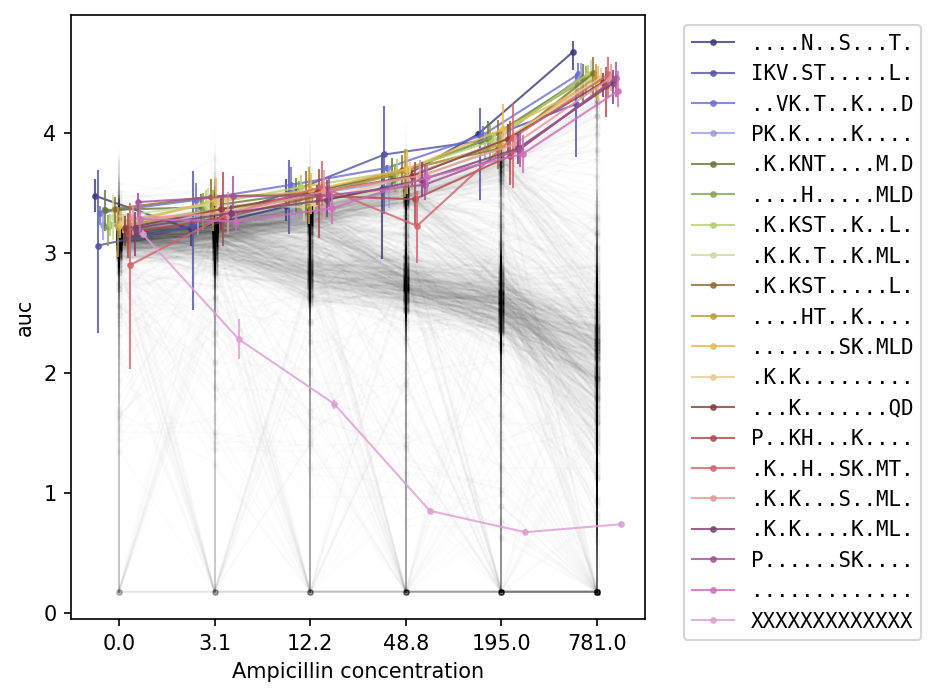

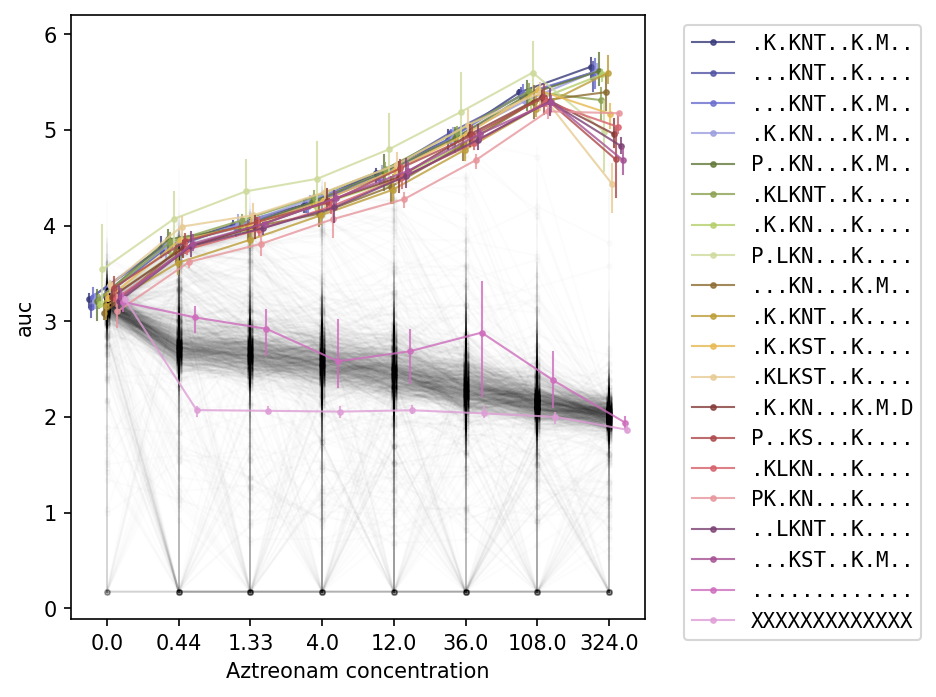

In [ ]:
for drug in drugs:
    fig, ax = plt.subplots(dpi=150)

    ax = sns.pointplot(long[drug], x='conc', y='auc', hue='genotype',
                        palette='dark:black', alpha=0.01, linewidth=1, legend=False, ax=ax)

    ax = sns.pointplot(longtop[drug], x='conc', y='auc', hue='genotype',
                        palette='tab20b', alpha=0.8, linewidth=1, dodge=True, ax=ax)
    L = ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.set_xlabel(f'{drug} concentration')
    plt.setp(L.texts, family='monospace')
    plt.tight_layout()
    fig.savefig(f'top genotypes {drug}.png', dpi=300, bbox_inches='tight')